# EDA: CFPB Category Prediction

# 0. Постановка задачи

Цель проекта — построить модель, которая по тексту жалобы определяет категорию обращения.

Целевая переменная:
category = product | issue


# 1. Первичный анализ данных (Data Audit)

Датасет содержит:
- ~555k записей
- 18 колонок
- текст жалобы (consumer_complaint_narrative)
- категории (product, issue)

Ключевые наблюдения:

1. Большое количество пропусков:
- consumer_complaint_narrative ~88%
- многие вспомогательные поля тоже разрежены

2. Важные поля без пропусков:
- product
- issue

3. Типы данных:
- почти все поля — строковые

Вывод:
- для задачи классификации будем использовать только записи с текстом

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [28]:
# Explicit dtype for mixed-type warning columns.
df = pd.read_csv("C:\\Users\\nurs\\OneDrive\\Рабочий стол\\RiskAware Complaints Engine\\data\\raw\\cfpb_complaints.csv", dtype={'zipcode': str}, low_memory=False)
df.head()


,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zipcode,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed?,complaint_id
0,08/30/2013,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,U.S. Bancorp,CA,95993,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511074
1,08/30/2013,Mortgage,Other mortgage,"Loan servicing, payments, escrow account",NaN,NaN,NaN,Wells Fargo & Company,CA,91104,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511080
2,08/30/2013,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,Wells Fargo & Company,NY,11764,NaN,NaN,Postal mail,09/18/2013,Closed with explanation,Yes,No,510473
3,08/30/2013,Student loan,Non-federal student loan,Repaying your loan,Repaying your loan,NaN,NaN,"Navient Solutions, Inc.",MD,21402,NaN,NaN,Email,08/30/2013,Closed with explanation,Yes,Yes,510326
4,08/30/2013,Debt collection,Credit card,False statements or representation,Attempted to collect wrong amount,NaN,NaN,Resurgent Capital Services L.P.,GA,30106,NaN,NaN,Web,08/30/2013,Closed with explanation,Yes,Yes,511067


In [29]:
df.shape


(555957, 18)

In [30]:
df.columns.tolist()


['date_received',
 'product',
 'sub_product',
 'issue',
 'sub_issue',
 'consumer_complaint_narrative',
 'company_public_response',
 'company',
 'state',
 'zipcode',
 'tags',
 'consumer_consent_provided',
 'submitted_via',
 'date_sent_to_company',
 'company_response_to_consumer',
 'timely_response',
 'consumer_disputed?',
 'complaint_id']

In [31]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555957 entries, 0 to 555956
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   date_received                 555957 non-null  object
 1   product                       555957 non-null  object
 2   sub_product                   397635 non-null  object
 3   issue                         555957 non-null  object
 4   sub_issue                     212622 non-null  object
 5   consumer_complaint_narrative  66806 non-null   object
 6   company_public_response       85124 non-null   object
 7   company                       555957 non-null  object
 8   state                         551070 non-null  object
 9   zipcode                       551452 non-null  object
 10  tags                          77959 non-null   object
 11  consumer_consent_provided     123458 non-null  object
 12  submitted_via                 555957 non-null  object
 13 

In [32]:
(df.isna().mean().sort_values(ascending=False) * 100).head(20)


consumer_complaint_narrative    87.983603
tags                            85.977513
company_public_response         84.688744
consumer_consent_provided       77.793606
sub_issue                       61.755675
sub_product                     28.477382
state                            0.879025
zipcode                          0.810314
date_sent_to_company             0.000000
consumer_disputed?               0.000000
timely_response                  0.000000
company_response_to_consumer     0.000000
date_received                    0.000000
submitted_via                    0.000000
product                          0.000000
company                          0.000000
issue                            0.000000
complaint_id                     0.000000
dtype: float64

In [33]:
df.duplicated().mean()


0.0

# 1.3 Распределение данных по времени

Проверили распределение жалоб по годам.

Наблюдения:
- данные покрывают период 2011–2016
- рост количества жалоб до 2015 года
- затем спад

Зачем это важно:
- возможен data drift (изменение распределения со временем)
- в будущем можно использовать temporal split (обучение на старых, тест на новых)

date_received
2011      2549
2012     72523
2013    108273
2014    153138
2015    168621
2016     50853
Name: count, dtype: int64

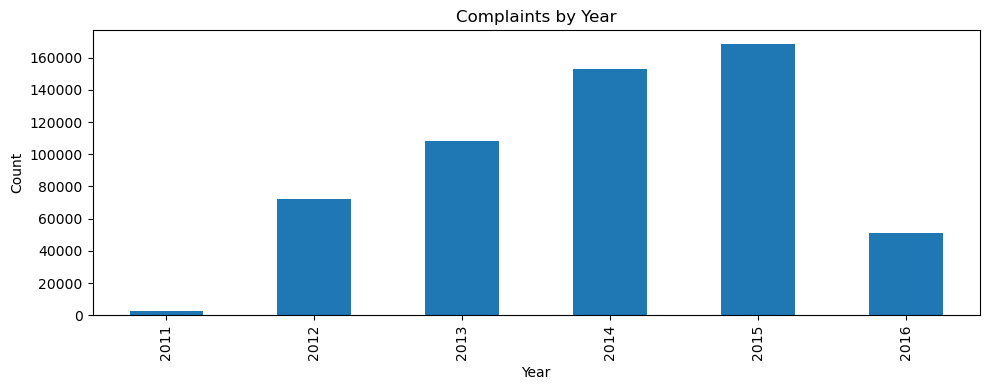

In [34]:
if 'date_received' in df.columns:
    df['date_received'] = pd.to_datetime(df['date_received'], errors='coerce')
    yearly = df['date_received'].dt.year.value_counts().sort_index()
    display(yearly)
    plt.figure(figsize=(10, 4))
    yearly.plot(kind='bar')
    plt.title('Complaints by Year')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('date_received column is missing')


# 2. Доступность текста и риск смещения (Bias)

Только ~12% записей содержат текст жалобы.

Мы формируем подвыборку:
df_text = записи, где есть текст

Проблема:
- модель обучается не на всех данных
- возможен selection bias

Дополнительно проверили:
- распределение product в полном датасете
- распределение product в df_text

Наблюдение:
- распределения отличаются (например, Debt collection чаще имеет текст)

Вывод:

Риск:
модель обучается на смещенной выборке

Следствие:
результаты могут хуже переноситься на весь поток жалоб

In [35]:
df['consumer_complaint_narrative'].isna().value_counts(normalize=True)


consumer_complaint_narrative
True     0.879836
False    0.120164
Name: proportion, dtype: float64

In [36]:
df_text = df.dropna(subset=['consumer_complaint_narrative']).copy()
df_text = df_text[df_text['consumer_complaint_narrative'].astype(str).str.strip() != ''].copy()
len(df_text), len(df)


(66806, 555957)

In [37]:
raw_product_dist = df['product'].value_counts(normalize=True)
text_product_dist = df_text['product'].value_counts(normalize=True)
comparison = pd.concat([raw_product_dist, text_product_dist], axis=1)
comparison.columns = ['raw_share', 'text_share']
comparison['delta'] = comparison['text_share'] - comparison['raw_share']
comparison.sort_values('delta', ascending=False).head(15)


,raw_share,text_share,delta
product,,,
Debt collection,0.181762,0.262731,0.080969
Credit reporting,0.165218,0.187498,0.022280
Consumer Loan,0.037755,0.055055,0.017300
Prepaid card,0.004443,0.012888,0.008445
Payday loan,0.006974,0.010867,0.003894
Student loan,0.028490,0.031853,0.003364
Money transfers,0.006857,0.009969,0.003113
Other financial service,0.001002,0.001647,0.000645
Credit card,0.119556,0.118687,-0.000869


# 3. Формирование рабочего датасета

Оставляем только необходимые поля:
- текст жалобы
- product
- issue

Дополнительно:
- удаляем записи без product/issue
- убираем слишком короткие тексты (мало информации)

Результат:
~66k записей для обучения

Наблюдение:
- средняя длина текста ~1000 символов
- тексты достаточно длинные и информативные

In [38]:
# Text length before additional filtering.
text_len_before = df_text['consumer_complaint_narrative'].astype(str).str.len()
text_len_before.describe()


count    66806.000000
mean      1039.587327
std        910.270430
min         10.000000
25%        391.000000
50%        740.000000
75%       1383.000000
max       5153.000000
Name: consumer_complaint_narrative, dtype: float64

In [39]:
df_filtered = df_text[['consumer_complaint_narrative', 'product', 'issue']].copy()
df_filtered = df_filtered.dropna(subset=['product', 'issue'])
# Remove very short narratives as likely low-information noise.
df_filtered = df_filtered[df_filtered['consumer_complaint_narrative'].astype(str).str.len() > 20].copy()
df_filtered.info()


<class 'pandas.core.frame.DataFrame'>
Index: 66777 entries, 190126 to 553096
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   consumer_complaint_narrative  66777 non-null  object
 1   product                       66777 non-null  object
 2   issue                         66777 non-null  object
dtypes: object(3)
memory usage: 2.0+ MB


# 4. Формирование целевой переменной

Создаем:
category = product | issue

Рассматривались варианты:
- только product → слишком грубо
- только issue → слишком детально и шумно
- product|issue → оптимальный баланс

Проверка:
- пропусков в target нет

Итого:
используем category как целевую переменную

In [40]:
df_filtered['category'] = df_filtered['product'].astype(str) + '|' + df_filtered['issue'].astype(str)


In [41]:
df_filtered['category'].isna().sum()


0

# 5. Распределение классов

Всего классов:
~99

Наблюдения:
- сильный дисбаланс
- есть категории с тысячами примеров
- есть категории с 1–10 примерами

Разделение:

- Head (>1000): ~19 классов
- Mid (100–1000): ~35 классов
- Tail (<100): ~45 классов

Это классический long-tail.

Решение (baseline):

- оставляем все классы
- используем Macro-F1 как метрику

Почему:
- хотим оценить реальную сложность задачи
- не искажаем распределение

Tail-обработку (объединение классов) оставляем на следующую итерацию

In [42]:
df_filtered['category'].nunique()


99

In [43]:
df_filtered['category'].value_counts().describe()


count      99.000000
mean      674.515152
std      1437.727213
min         1.000000
25%        21.500000
50%       179.000000
75%       618.500000
max      8344.000000
Name: count, dtype: float64

In [44]:
counts = df_filtered['category'].value_counts()
head_classes = (counts > 1000).sum()
mid_classes = ((counts >= 100) & (counts <= 1000)).sum()
tail_classes = (counts < 100).sum()
{'head_gt_1000': int(head_classes), 'mid_100_1000': int(mid_classes), 'tail_lt_100': int(tail_classes)}


{'head_gt_1000': 19, 'mid_100_1000': 35, 'tail_lt_100': 45}

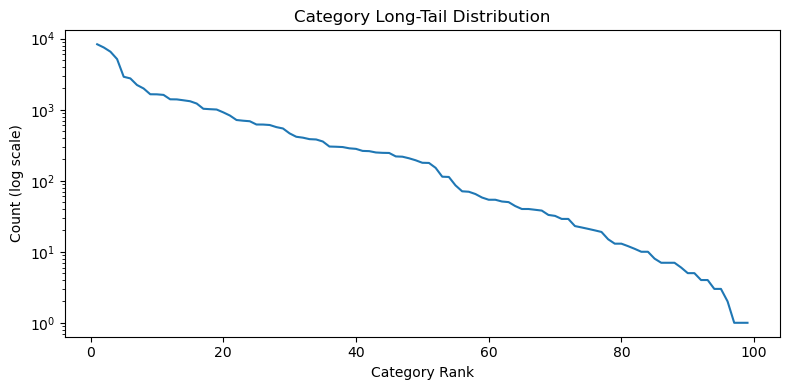

In [45]:
plt.figure(figsize=(8, 4))
ranks = np.arange(1, len(counts) + 1)
plt.plot(ranks, counts.values)
plt.yscale('log')
plt.xlabel('Category Rank')
plt.ylabel('Count (log scale)')
plt.title('Category Long-Tail Distribution')
plt.tight_layout()
plt.show()


# 6. Анализ текста (качество и шум)

Основные наблюдения:

1. Длина текста:
- средняя ~1000 символов
- есть длинные тексты (до 5000)

2. Анонимизация:
- часто встречается "XXXX"
- около 85% текстов содержат такие токены

3. Частотные слова:
- много служебных слов (the, and, to)
- доменные слова (credit, loan, account)

Решение:

- для TF-IDF:
  считать "xxxx" шумом

- для нейронных моделей:
  оставить, так как может нести структурную информацию

In [46]:
text_len = df_filtered['consumer_complaint_narrative'].astype(str).str.len()
text_len.describe()


count    66777.000000
mean      1040.031658
std        910.218262
min         21.000000
25%        391.000000
50%        741.000000
75%       1384.000000
max       5153.000000
Name: consumer_complaint_narrative, dtype: float64

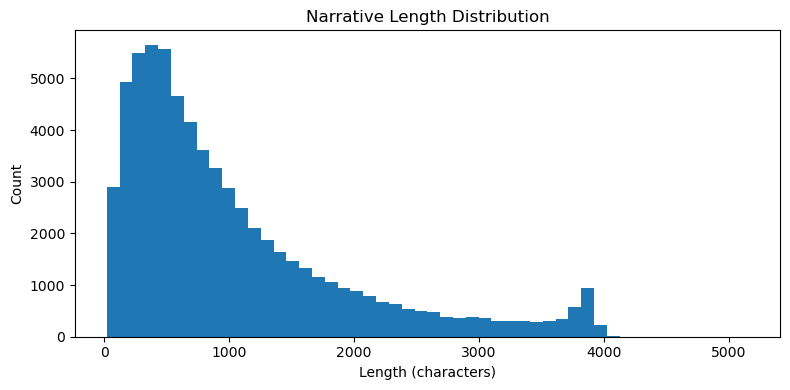

In [47]:
plt.figure(figsize=(8, 4))
plt.hist(text_len, bins=50)
plt.title('Narrative Length Distribution')
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [48]:
df_filtered['consumer_complaint_narrative'].str.contains(r'[^a-zA-Z ]', regex=True, na=False).mean()


0.9999550743519475

In [49]:
df_filtered['consumer_complaint_narrative'].str.contains(r'X{3,}', regex=True, na=False).mean()


0.8497386824804948

In [50]:
token_counter = Counter()
for text in df_filtered['consumer_complaint_narrative'].astype(str).head(20000):
    tokens = re.findall(r'[a-zA-Z]+', text.lower())
    token_counter.update(tokens)

token_counter.most_common(40)


[('xxxx', 187196),
 ('the', 154848),
 ('i', 145514),
 ('to', 129947),
 ('and', 103750),
 ('a', 78904),
 ('my', 76122),
 ('of', 59775),
 ('that', 59008),
 ('was', 53274),
 ('they', 47431),
 ('in', 45913),
 ('on', 41321),
 ('have', 39173),
 ('for', 38801),
 ('not', 38277),
 ('this', 37967),
 ('me', 37014),
 ('is', 34916),
 ('with', 31428),
 ('it', 28912),
 ('credit', 25447),
 ('xx', 22945),
 ('from', 22560),
 ('account', 21379),
 ('as', 18156),
 ('had', 17955),
 ('be', 16425),
 ('them', 15816),
 ('we', 15330),
 ('loan', 14742),
 ('would', 14630),
 ('by', 13397),
 ('at', 13346),
 ('payment', 13142),
 ('bank', 12792),
 ('an', 12750),
 ('been', 12678),
 ('but', 12507),
 ('are', 12492)]

**Decision (anonymization tokens):**
Treat `xxxx`-style anonymized tokens as noise for TF-IDF,
but keep them for neural models where structural context may still help.


# 7. Дубликаты

Доля дубликатов:
~1.6%

Решение:
- оставить дубликаты в baseline

Причина:
- дубликаты могут отражать реальные повторяющиеся жалобы

Дальше:
- при анализе ошибок можно удалить дубликаты

In [51]:
df_filtered.duplicated().mean()


0.016577564131362594

# 8. Ограничения модели

Используемые признаки:
- только текст

Планируемые модели:
- TF-IDF + Logistic Regression
- LSTM
- Transformer (BERT)

Вывод из EDA:

- тексты длинные → нужна обрезка (truncation)
- для трансформеров потребуется ограничение длины (например, 512 токенов)

# 9. Стратегия разбиения

Основной вариант:
- stratified split по category

Почему:
- сохраняем распределение классов

Дополнительно (опционально):
- temporal split (по времени)
- проверка устойчивости к drift

# 10. Финальные решения для пайплайна

Данные:
- используем только записи с текстом (~66k)
- принимаем риск смещения (bias)

Target:
- category = product|issue

Текст:
- минимальная очистка
- специальные токены (xxxx) обрабатываются по-разному для разных моделей

Метрика:
- Macro-F1

Split:
- stratified

# 11. Сложность задачи

Задача сложная по следующим причинам:

- 99 классов
- сильный long-tail
- длинные тексты
- сильная анонимизация (XXXX)
- категории семантически близки

Вывод:
модель должна уметь хорошо обобщать и работать с шумом

# 12. Ожидания от baseline

Baseline (majority class):
~12–15% accuracy

Macro-F1 baseline:
очень низкий из-за большого числа классов

Ожидание:
модель должна значительно превзойти baseline

Основная метрика:
Macro-F1

# 13. Итог

Данные:
- ~66k текстовых жалоб
- ~88% исходных данных без текста

Target:
- 99 классов
- сильный дисбаланс

Текст:
- длинный (~1000 символов)
- присутствует шум и анонимизация

Решения:
- используем полный набор классов
- применяем stratified split
- оцениваем через Macro-F1

Следующий шаг:
обучение baseline модели